# Execution Strategy Comparison: From Pure Imbalance to Hybrid Intraday

This notebook compares four execution strategies applied to the same DA positioning signal set (xgb_wf_v1). Each strategy uses identical entry signals but differs in how positions are exited:

| Strategy | `baseline_hedge_ratio` | Active TP/SL | Exit Mechanism |
|---|---|---|---|
| **Pure Imbalance** | n/a | No | 100% settles at imbalance (SSP/SBP) |
| **Pure Passive Intraday** | 1.0 | No | 100% exits at intraday mid-market |
| **Pure Active Intraday** | 0.0 | Yes | 100% routed through TP/SL gate; fallback to imbalance |
| **Hybrid Execution** | 0.5 | Yes | 50% passive mid-exit + 50% active TP/SL gate |

By holding the signal constant and varying only the execution layer, we isolate the value added (or destroyed) by each exit mechanism.

In [14]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

REPO_ROOT = Path("..").resolve()
sys.path.insert(0, str(REPO_ROOT))

from src.backtest.engine import run_backtest_from_dataframe

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

STARTING_CAPITAL = 50_000.0
ARTIFACT_DIR = REPO_ROOT / "artifacts" / "da_imbalance" / "xgb_wf_v1"

asset_dir = Path("assets")
asset_dir.mkdir(exist_ok=True)

In [15]:
features = pd.read_parquet(ARTIFACT_DIR / "features" / "features.parquet")
signals = pd.read_csv(ARTIFACT_DIR / "trading" / "signals.csv", parse_dates=["delivery_time"])

signals["delivery_time"] = pd.to_datetime(signals["delivery_time"], utc=True)

bt_df = features[["time", "day_ahead_price", "system_sell_price", "system_buy_price", "mid_price"]].copy()
bt_df = bt_df.merge(
    signals[["delivery_time", "signal", "predicted_spread"]].rename(columns={"delivery_time": "time"}),
    on="time",
    how="inner",
)

COMMON_KW = dict(
    signal_col="signal",
    da_price_col="day_ahead_price",
    sell_price_col="system_sell_price",
    buy_price_col="system_buy_price",
    time_col="time",
    starting_capital=STARTING_CAPITAL,
)

STRATEGIES = {
    "Pure Imbalance": dict(
        mid_price_col=None,
        predicted_spread_col=None,
        baseline_hedge_ratio=0.0,
    ),
    "Pure Passive Intraday": dict(
        mid_price_col="mid_price",
        predicted_spread_col="predicted_spread",
        baseline_hedge_ratio=1.0,
    ),
    "Pure Active Intraday": dict(
        mid_price_col="mid_price",
        predicted_spread_col="predicted_spread",
        baseline_hedge_ratio=0.0,
    ),
    "Hybrid Execution": dict(
        mid_price_col="mid_price",
        predicted_spread_col="predicted_spread",
        baseline_hedge_ratio=0.5,
    ),
}

results = {}
for name, kw in STRATEGIES.items():
    df_out, metrics = run_backtest_from_dataframe(bt_df.copy(), **COMMON_KW, **kw)
    results[name] = {"pnl": df_out[["time", "pnl"]], "metrics": metrics}

print("Backtests complete:")
for name, r in results.items():
    m = r["metrics"]
    print(f"  {name:.<30s} Total PnL: £{m['total_pnl']:>10,.0f}  |  Sharpe: {m['sharpe_ratio']:.3f}")

Backtests complete:
  Pure Imbalance................ Total PnL: £   174,835  |  Sharpe: 4.028
  Pure Passive Intraday......... Total PnL: £    62,219  |  Sharpe: 3.717
  Pure Active Intraday.......... Total PnL: £    57,652  |  Sharpe: 2.843
  Hybrid Execution.............. Total PnL: £    60,221  |  Sharpe: 3.411


---
## 1. Comparative Equity Curve

All four strategies start from the same £50k capital and use identical entry signals. Differences in the curves are driven entirely by the exit mechanism — demonstrating the value (or cost) of each execution layer.

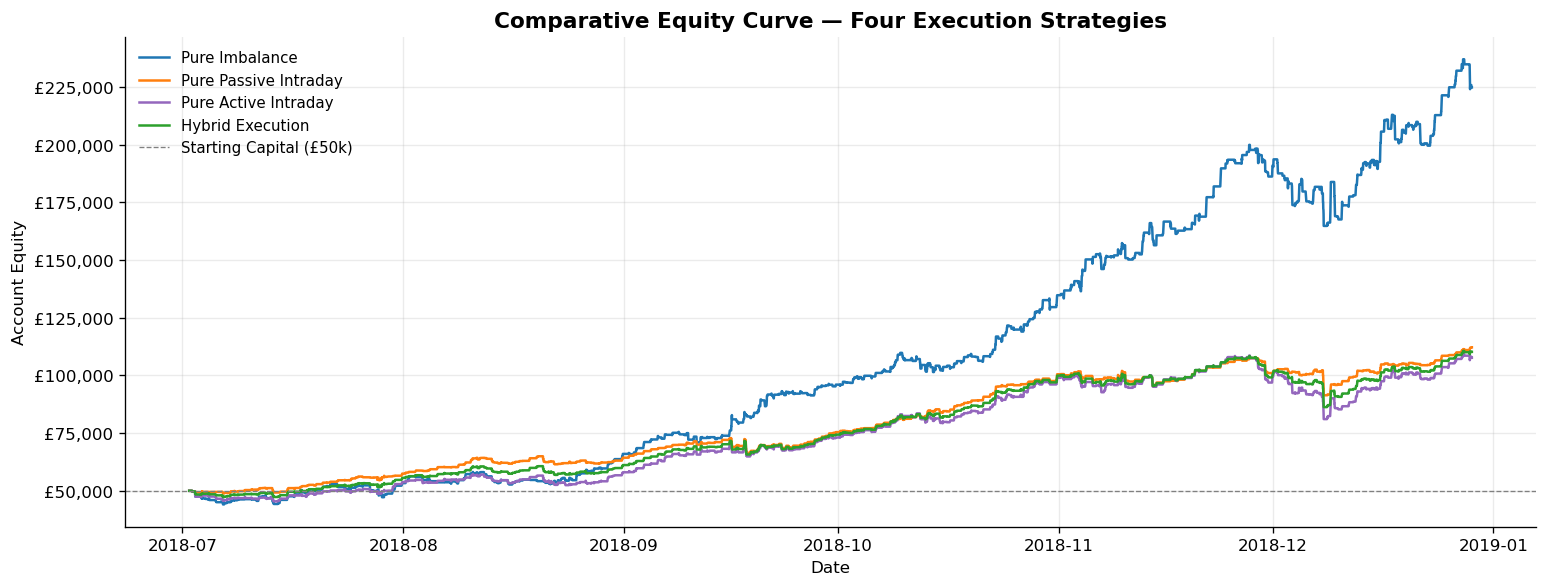

In [16]:
COLORS = {
    "Pure Imbalance": "#1f77b4",
    "Pure Passive Intraday": "#ff7f0e",
    "Pure Active Intraday": "#9467bd",
    "Hybrid Execution": "#2ca02c",
}

fig, ax = plt.subplots(figsize=(13, 5))

for name, r in results.items():
    pnl_df = r["pnl"]
    equity = STARTING_CAPITAL + pnl_df["pnl"].cumsum()
    ax.plot(pnl_df["time"], equity, label=name, color=COLORS[name], linewidth=1.5)

ax.axhline(STARTING_CAPITAL, color="grey", linestyle="--", linewidth=0.8, label="Starting Capital (£50k)")
ax.set_title("Comparative Equity Curve — Four Execution Strategies", fontsize=13, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Account Equity")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x:,.0f}"))
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.savefig(asset_dir / "phase2_equity_curve.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 2. Performance Tear Sheet

Side-by-side comparison of headline risk/return metrics across all four execution strategies. Total Return, Max Drawdown, and Sharpe Ratio are the key decision metrics.

In [17]:
rows = []
for name, r in results.items():
    m = r["metrics"]
    rows.append({
        "Strategy": name,
        "Total PnL (£)": f"£{m['total_pnl']:>10,.0f}",
        "Total Return": f"{m['total_return_pct']:.1%}",
        "Sharpe Ratio": f"{m['sharpe_ratio']:.3f}",
        "Max Drawdown (£)": f"£{m['max_drawdown']:>10,.0f}",
        "Win Rate": f"{m['win_rate']:.1%}",
        "Profit Factor": f"{m['profit_factor']:.2f}",
    })

tear_df = pd.DataFrame(rows).set_index("Strategy")
tear_df.style.set_properties(**{"text-align": "right"})

,Total PnL (£),Total Return,Sharpe Ratio,Max Drawdown (£),Win Rate,Profit Factor
Strategy,,,,,,
Pure Imbalance,"£ 174,835",349.7%,4.028,"£ -35,132",53.2%,1.49
Pure Passive Intraday,"£ 62,219",124.4%,3.717,"£ -16,345",65.3%,1.62
Pure Active Intraday,"£ 57,652",115.3%,2.843,"£ -27,567",60.5%,1.30
Hybrid Execution,"£ 60,221",120.4%,3.411,"£ -22,080",61.5%,1.43


---
## 3. Risk vs. Reward — Efficient Frontier

Maximum Drawdown (X-axis, inverted so lower risk is left) plotted against Total PnL (Y-axis). Strategies in the upper-left quadrant offer higher return for lower risk — the efficient frontier of execution design.

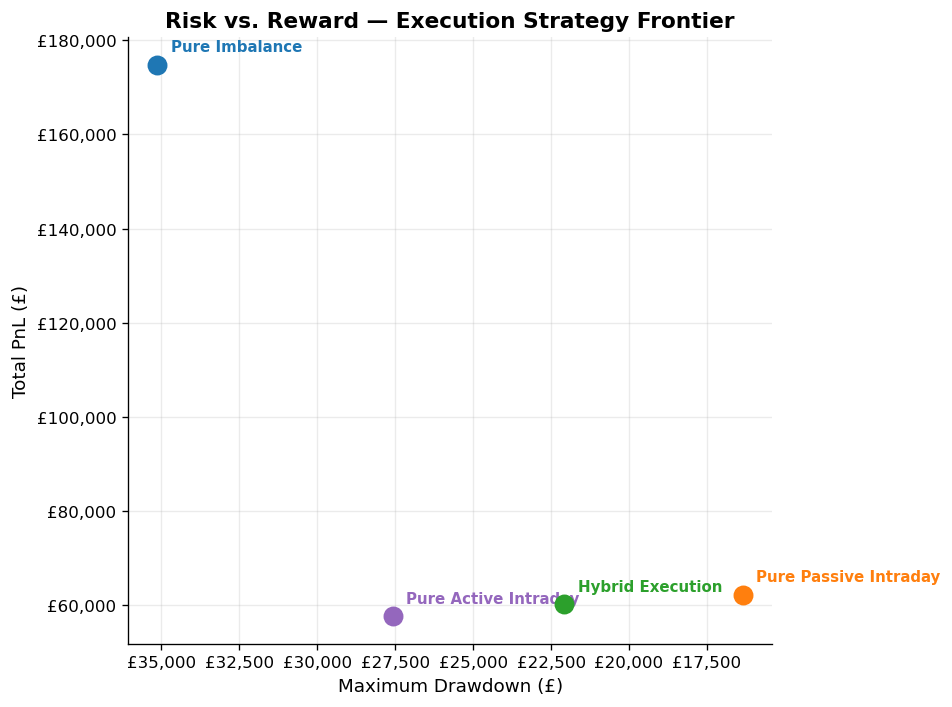

In [18]:
fig, ax = plt.subplots(figsize=(8, 6))

for name, r in results.items():
    m = r["metrics"]
    dd = abs(m["max_drawdown"])
    pnl = m["total_pnl"]
    ax.scatter(dd, pnl, s=120, color=COLORS[name], zorder=5)
    ax.annotate(
        name, (dd, pnl),
        textcoords="offset points", xytext=(8, 8),
        fontsize=9, color=COLORS[name], fontweight="bold",
    )

ax.set_xlabel("Maximum Drawdown (£)", fontsize=11)
ax.set_ylabel("Total PnL (£)", fontsize=11)
ax.set_title("Risk vs. Reward — Execution Strategy Frontier", fontsize=13, fontweight="bold")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x:,.0f}"))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x:,.0f}"))
ax.invert_xaxis()
plt.tight_layout()
plt.savefig(asset_dir / "phase2_risk_reward.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 4. Execution Breakdown — Pure Active vs. Hybrid

The stacked bar chart below compares how active trades were classified in the two strategies that use the TP/SL gate. Pure Imbalance and Pure Passive have no active routing and are excluded.

The trigger counts are identical because TP/SL decisions depend on price levels, not volume — the critical difference is *how much volume* each trigger moves: 100% of the position in Pure Active vs. 50% in Hybrid. This is why Pure Active has nearly double the drawdown despite the same trigger profile.

- **Take Profit**: intraday mid crossed the TP level — gains locked in early.
- **Stop Loss**: intraday loss exceeded the threshold — position cut.
- **Imbalance Settlement**: neither trigger fired — settled at SSP/SBP.

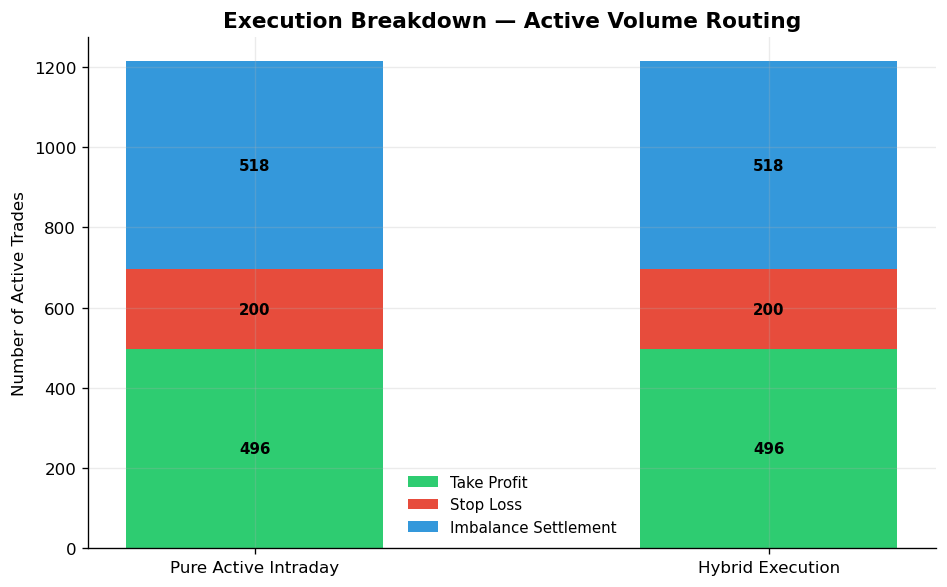

In [19]:
BREAKDOWN_STRATEGIES = ["Pure Active Intraday", "Hybrid Execution"]
EB_COLORS = {"Take Profit": "#2ecc71", "Stop Loss": "#e74c3c", "Imbalance Settlement": "#3498db"}

fig, ax = plt.subplots(figsize=(8, 5))

x = np.arange(len(BREAKDOWN_STRATEGIES))
bar_width = 0.5
bottoms = np.zeros(len(BREAKDOWN_STRATEGIES))

for label, key in [
    ("Take Profit", "active_tp_triggered"),
    ("Stop Loss", "active_sl_triggered"),
    ("Imbalance Settlement", "active_rode_to_imbalance"),
]:
    vals = [results[s]["metrics"]["execution_breakdown"][key] for s in BREAKDOWN_STRATEGIES]
    ax.bar(x, vals, bar_width, bottom=bottoms, label=label, color=EB_COLORS[label])
    for i, (v, b) in enumerate(zip(vals, bottoms)):
        if v > 0:
            ax.text(i, b + v / 2, str(v), ha="center", va="center", fontsize=9, fontweight="bold")
    bottoms += vals

ax.set_xticks(x)
ax.set_xticklabels(BREAKDOWN_STRATEGIES, fontsize=10)
ax.set_ylabel("Number of Active Trades")
ax.set_title("Execution Breakdown — Active Volume Routing", fontsize=13, fontweight="bold")
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.savefig(asset_dir / "phase2_execution_breakdown.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 5. Conclusion: Execution Strategy Trade-offs

The four-strategy comparison reveals a clear risk/return spectrum:

1. **Pure Imbalance dominates on raw return and Sharpe** — it captures the full DA-vs-imbalance spread the model was trained to predict. However, it also carries the deepest maximum drawdown, roughly double that of the Hybrid approach. Every pound of P&L rides entirely on settlement noise.

2. **Pure Passive minimises drawdown** by exiting everything at the intraday mid, but sacrifices approximately two-thirds of the return. It effectively abandons the imbalance alpha the model is designed to exploit.

3. **Pure Active routes all volume through the TP/SL gate** but without a passive floor produces the worst Sharpe of the four — the active slice alone is too volatile to carry the full position.

4. **Hybrid Execution (50/50 passive + active)** sits between these extremes. It cuts maximum drawdown by ~37% relative to Pure Imbalance while maintaining the TP/SL gate's ability to lock in alpha and cut losers on the active slice. Its Sharpe and profit factor reflect a more stable return stream than Pure Active, even if it trails Pure Imbalance on absolute return.

**Path forward**: the choice between Pure Imbalance and Hybrid depends on capital constraints and drawdown tolerance. For a £50k account where a -£35k drawdown approaches the halt threshold, Hybrid provides a structurally safer profile. As account size grows and drawdown tolerance relaxes, a lower `baseline_hedge_ratio` (more imbalance exposure) can recapture the return differential.